# Question 1

### 1.	How does the number of rest days between appearances affect fastball velocity and spin rate for MLB relief pitchers?

In [2]:
# Question 1: How does rest days affect fastball velocity and spin rate?
# Relief Pitchers (2021-2024)

import polars as pl
import numpy as np
import pandas as pd
from plotnine import *
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load outing-level data
(outing_table := pl.read_parquet('data/outing_table.parquet')).head(3)

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124


## Part 1: Individual Variability
Exploring how individual pitchers respond to different rest intervals

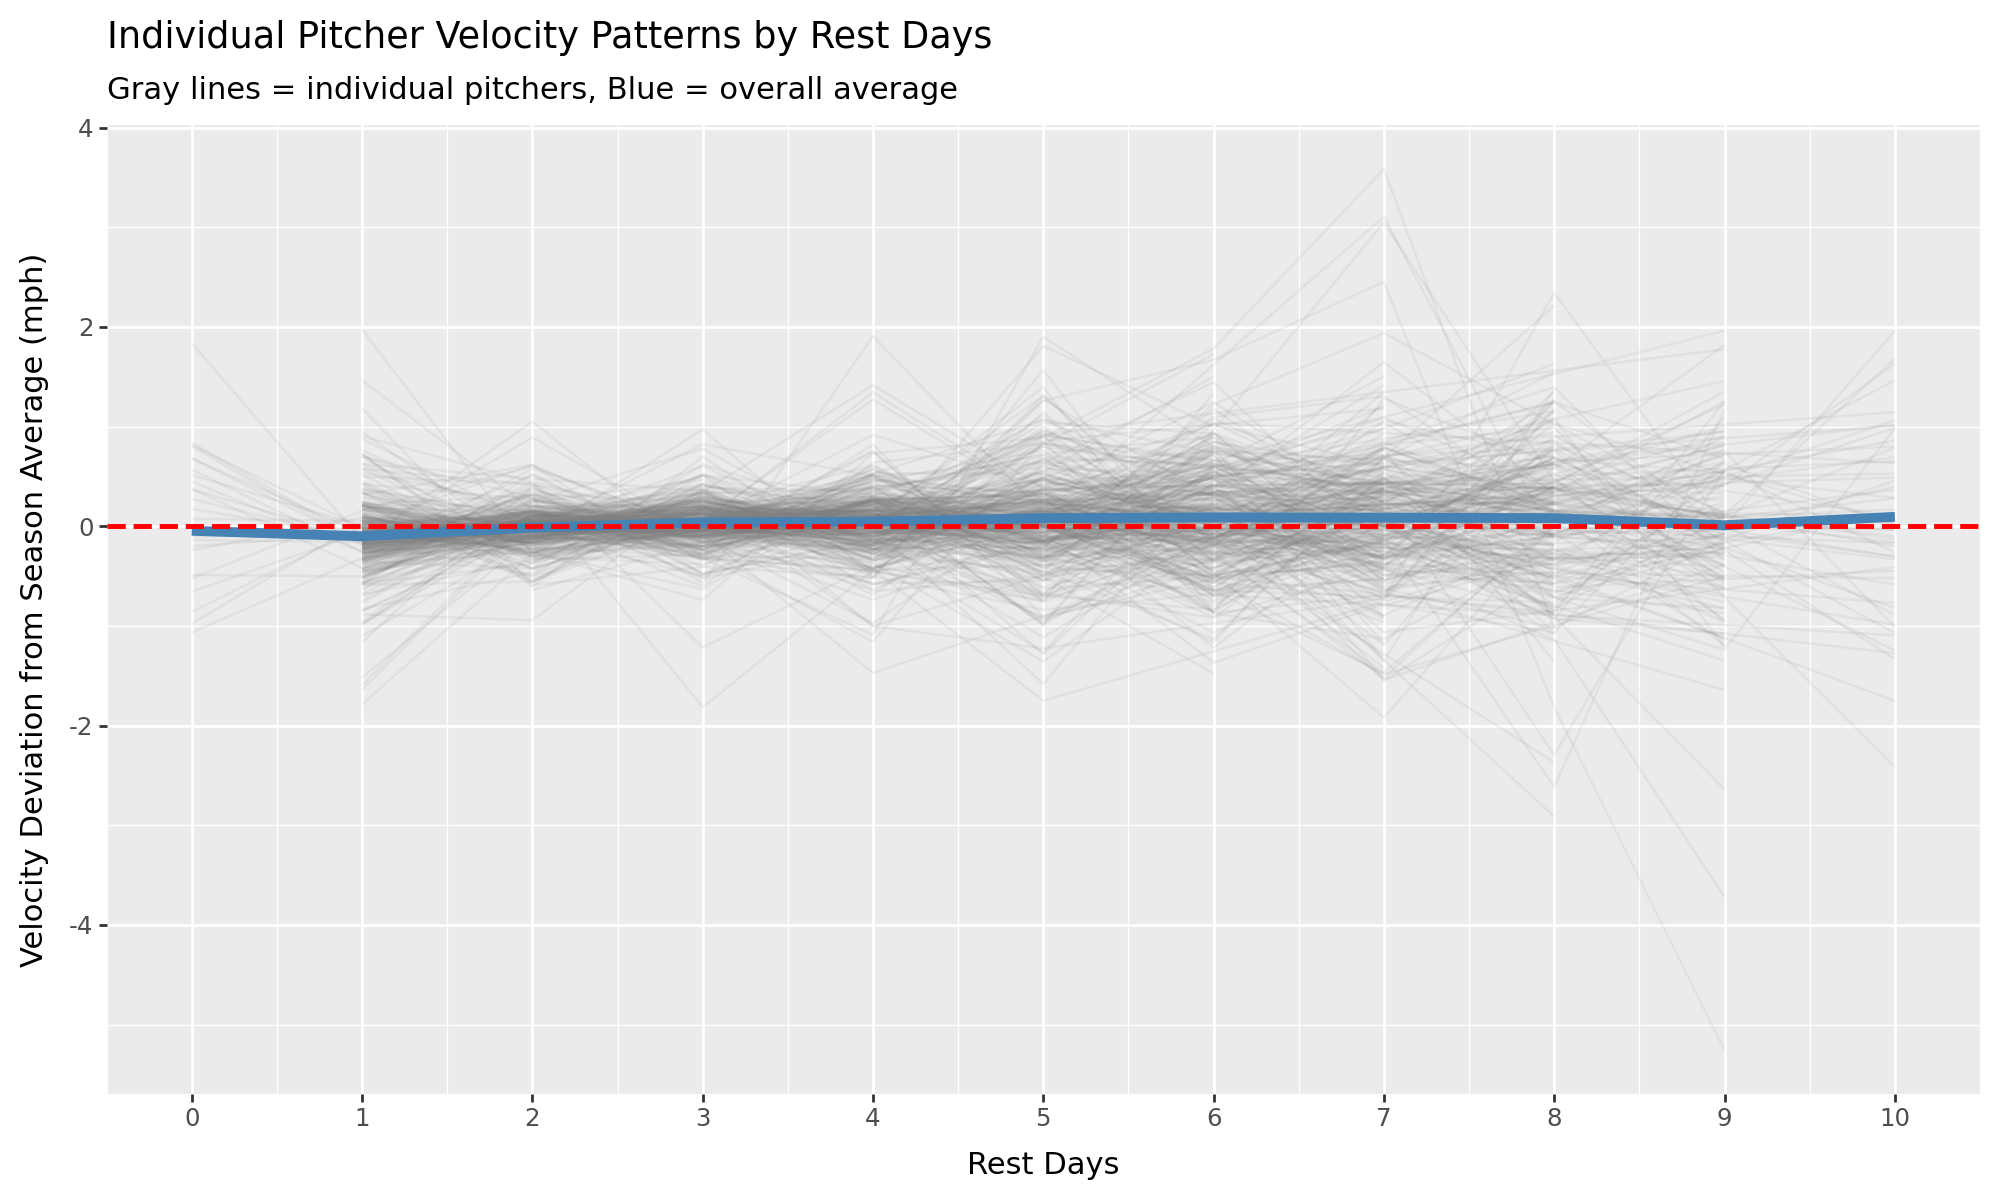

In [4]:
# Individual pitcher velocity patterns (spaghetti plot)
pitcher_velo_by_rest = (outing_table
    .filter(pl.col('rest_days') <= 10)
    .group_by(['pitcher_id', 'pitcher_name', 'rest_days'])
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo'),
    ])
    .sort(['pitcher_id', 'rest_days'])
    .to_pandas()
)

# Overall mean for bold line
overall_mean = (outing_table
    .filter(pl.col('rest_days') <= 10)
    .group_by('rest_days')
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo'),
    ])
    .sort('rest_days')
    .to_pandas()
)

(ggplot() +
 geom_line(data=pitcher_velo_by_rest, 
           mapping=aes(x='rest_days', y='mean_velo', group='pitcher_id'),
           color='gray', alpha=0.1, size=0.5) +
 geom_line(data=overall_mean,
           mapping=aes(x='rest_days', y='mean_velo'),
           color='steelblue', size=2) +
 geom_hline(yintercept=0, linetype='dashed', color='red', size=1) +
 labs(title='Individual Pitcher Velocity Patterns by Rest Days',
      subtitle='Gray lines = individual pitchers, Blue = overall average',
      x='Rest Days',
      y='Velocity Deviation from Season Average (mph)') +
 scale_x_continuous(breaks=range(0, 11)) +
 theme(figure_size=(10, 6)))

## Part 2: Average Effects Across All Pitchers
Mean velocity and spin rate changes by rest days

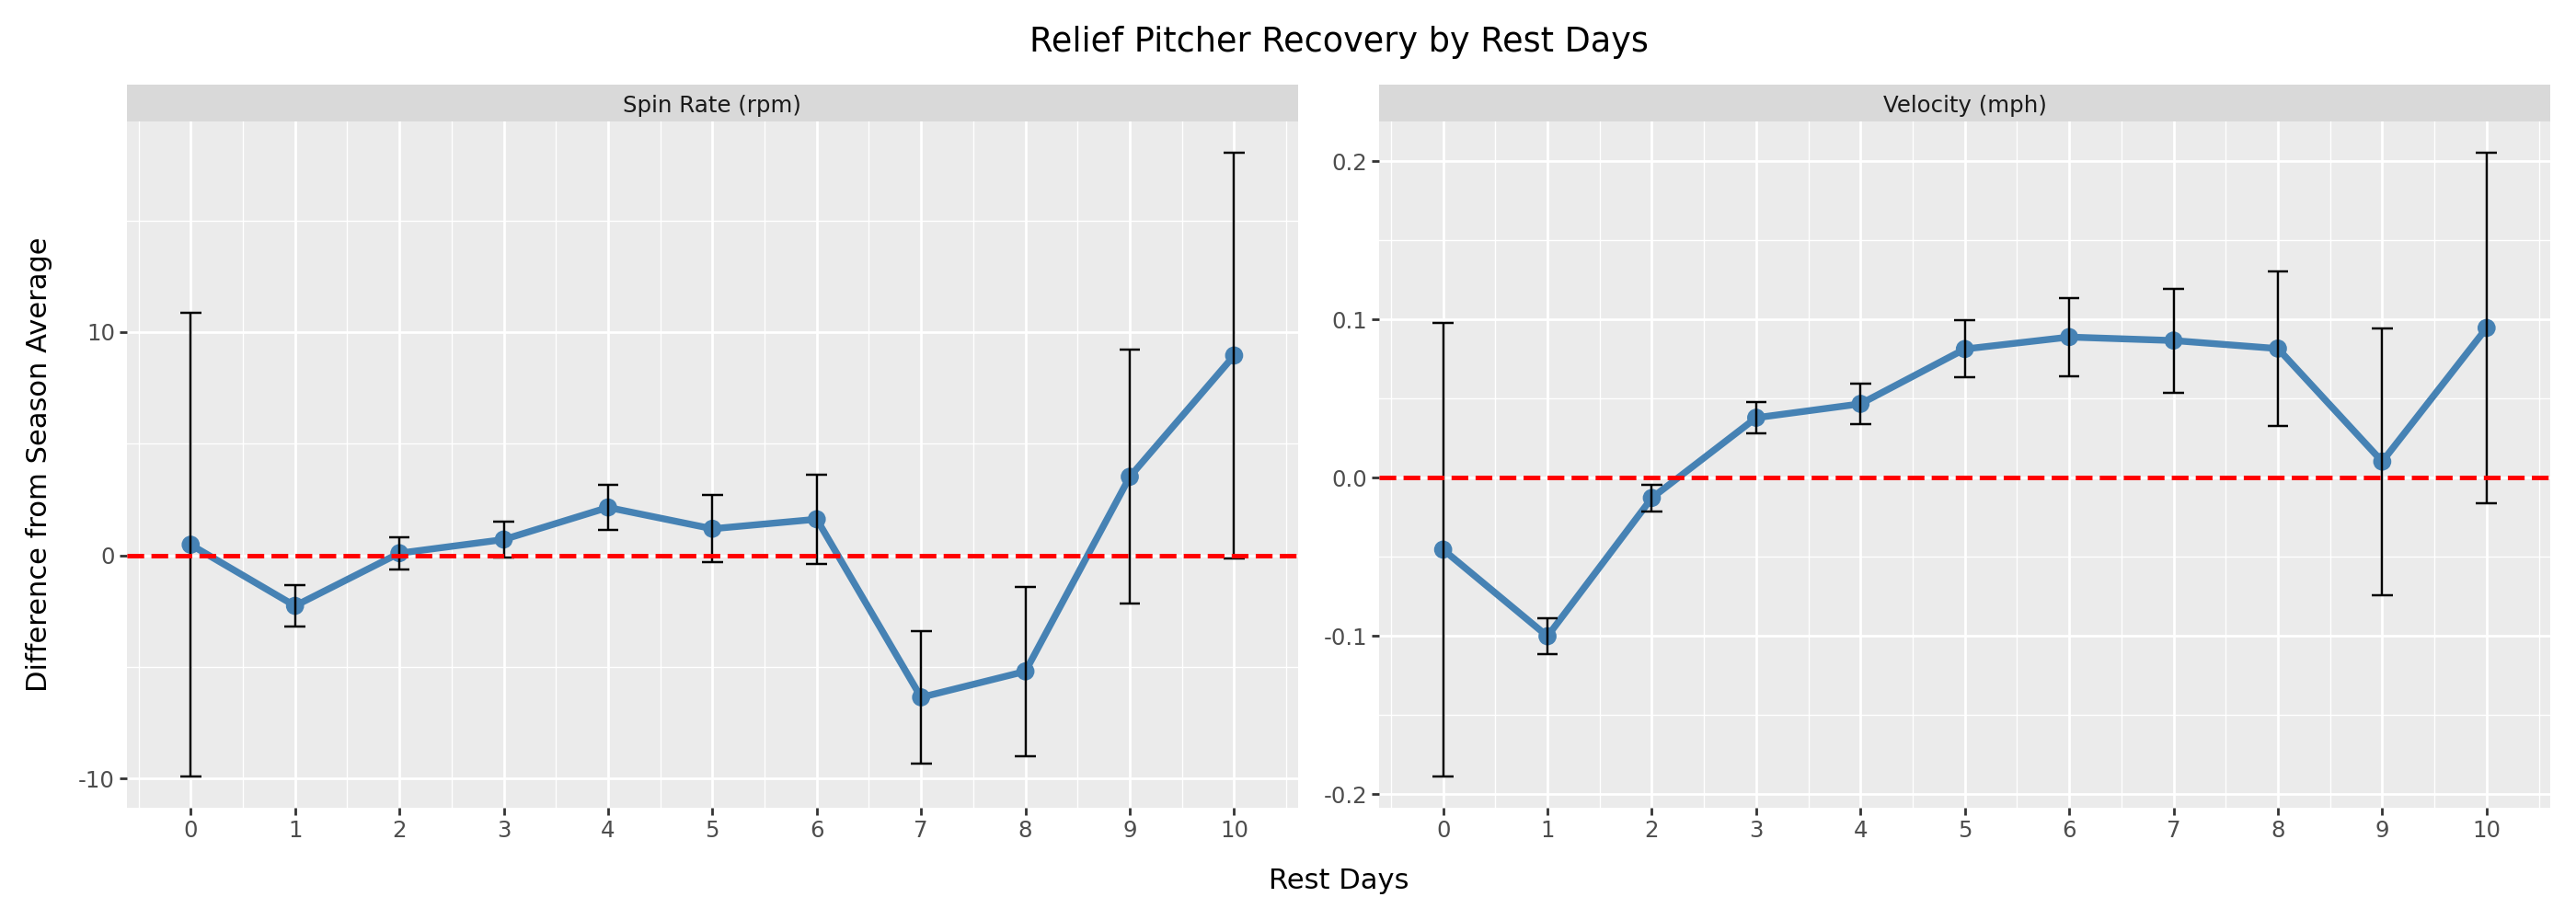

In [5]:
# Calculate velocity and spin deviations by rest days
df_velo_rest = (outing_table
    .filter(pl.col('rest_days') <= 10)
    .group_by('rest_days')
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo'),
        pl.col('velo_deviation').std().alias('std_velo'),
        pl.len().alias('n'),
    ])
    .with_columns([
        (pl.col('std_velo') / pl.col('n').sqrt()).alias('se')
    ])
    .sort('rest_days')
    .to_pandas()
)

df_spin_rest = (outing_table
    .filter(pl.col('rest_days') <= 10)
    .group_by('rest_days')
    .agg([
        pl.col('spin_deviation').mean().alias('mean_spin'),
        pl.col('spin_deviation').std().alias('std_spin'),
        pl.len().alias('n'),
    ])
    .with_columns([
        (pl.col('std_spin') / pl.col('n').sqrt()).alias('se')
    ])
    .sort('rest_days')
    .to_pandas()
)

# Prepare for side-by-side plot
df_velo_rest['metric'] = 'Velocity (mph)'
df_velo_rest['value'] = df_velo_rest['mean_velo']

df_spin_rest['metric'] = 'Spin Rate (rpm)'
df_spin_rest['value'] = df_spin_rest['mean_spin']

# Combine
combined = pd.concat([
    df_velo_rest[['rest_days', 'value', 'se', 'metric']],
    df_spin_rest[['rest_days', 'value', 'se', 'metric']]
])

(ggplot(combined, aes(x='rest_days', y='value')) +
 geom_line(color='steelblue', size=1.5) +
 geom_point(color='steelblue', size=3) +
 geom_errorbar(aes(ymin='value - se', ymax='value + se'), width=0.2) +
 geom_hline(yintercept=0, linetype='dashed', color='red', size=1) +
 facet_wrap('~metric', scales='free_y', ncol=2) +
 labs(title='Relief Pitcher Recovery by Rest Days',
      x='Rest Days',
      y='Difference from Season Average') +
 scale_x_continuous(breaks=range(0, 11)) +
 theme(figure_size=(14, 5)))

## Regression Test

In [6]:


X = outing_table.filter(pl.col('rest_days') <= 10)['rest_days'].to_numpy()
y_velo = outing_table.filter(pl.col('rest_days') <= 10)['velo_deviation'].to_numpy()
y_spin = outing_table.filter(pl.col('rest_days') <= 10)['spin_deviation'].to_numpy()

# Velocity regression
slope_v, intercept_v, r_v, p_v, se_v = stats.linregress(X, y_velo)

# Spin regression
slope_s, intercept_s, r_s, p_s, se_s = stats.linregress(X, y_spin)

print("VELOCITY REGRESSION")
print(f"  Slope: +{slope_v:.4f} mph per rest day")
print(f"  p-value: {p_v:.4f}")
print(f"  Significant: {p_v < 0.05}")
print(f"\nSPIN RATE REGRESSION")
print(f"  Slope: +{slope_s:.4f} rpm per rest day")
print(f"  p-value: {p_s:.4f}")
print(f"  Significant: {p_s < 0.05}")

VELOCITY REGRESSION
  Slope: +0.0320 mph per rest day
  p-value: 0.0000
  Significant: True

SPIN RATE REGRESSION
  Slope: +0.3849 rpm per rest day
  p-value: 0.1172
  Significant: False


## Adding Pitch Count with Rest

In [7]:
# Add pitch count groups and rest day groups
(outing_with_groups := (outing_table
    .filter(pl.col('rest_days') <= 10)  # Consistent with Q1 analysis
    .with_columns([
        pl.when(pl.col('prev_pitch_count') <= 15)
          .then(pl.lit('Low (≤15)'))
          .when(pl.col('prev_pitch_count') <= 25)
          .then(pl.lit('Medium (16-25)'))
          .otherwise(pl.lit('High (>25)'))
          .alias('prev_pitch_group'),

        pl.when(pl.col('rest_days') <= 1)
          .then(pl.lit('Short (0-1)'))
          .when(pl.col('rest_days') <= 3)
          .then(pl.lit('Normal (2-3)'))
          .otherwise(pl.lit('Long (4+)'))
          .alias('rest_group'),
    ])
))

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,prev_pitch_group,rest_group
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,str,str
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,"""High (>25)""","""Normal (2-3)"""
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,"""Medium (16-25)""","""Short (0-1)"""
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124,"""Low (≤15)""","""Normal (2-3)"""
433589,632231,2021-04-12 00:00:00,2021,"""Yusmeiro Petit""",7,86.357143,87.7,2242.0,-0.18,1.548571,6,"""R""",3,3,10,8,86.615973,2137.198876,-0.25883,104.801124,"""Low (≤15)""","""Normal (2-3)"""
433589,632206,2021-04-13 00:00:00,2021,"""Yusmeiro Petit""",4,86.7,88.3,2058.5,-0.0875,1.3625,7,"""R""",0,1,6,10,86.615973,2137.198876,0.084027,-78.698876,"""Low (≤15)""","""Short (0-1)"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,746985,2024-09-19 00:00:00,2024,"""Spencer Bivens""",32,94.1,97.5,2093.96875,-0.650938,0.590938,8,"""R""",-1,4,37,13,94.048879,1941.835625,0.051121,152.133125,"""Low (≤15)""","""Long (4+)"""
702352,746255,2024-09-21 00:00:00,2024,"""Spencer Bivens""",18,95.127778,97.2,2105.0,-0.842222,0.501667,7,"""R""",9,2,28,37,94.048879,1941.835625,1.078899,163.164375,"""High (>25)""","""Normal (2-3)"""
702352,747150,2024-09-23 00:00:00,2024,"""Spencer Bivens""",14,94.907143,97.1,2092.5,-0.977857,0.445714,6,"""R""",3,2,21,28,94.048879,1941.835625,0.858264,150.664375,"""High (>25)""","""Normal (2-3)"""


In [8]:
(pitch_count_summary := outing_with_groups.group_by(['prev_pitch_group', 'rest_group']).agg([
    pl.col('velo_deviation').mean().alias('mean_velo_diff'),
    pl.col('spin_deviation').mean().alias('mean_spin_diff'),
    pl.len().alias('count'),
]).sort(['prev_pitch_group', 'rest_group']))

prev_pitch_group,rest_group,mean_velo_diff,mean_spin_diff,count
str,str,f64,f64,u32
"""High (>25)""","""Long (4+)""",0.015039,-1.219382,1873
"""High (>25)""","""Normal (2-3)""",-0.050138,-0.216538,2590
"""High (>25)""","""Short (0-1)""",-0.304129,-6.854111,324
"""Low (≤15)""","""Long (4+)""",0.081216,1.813814,4050
"""Low (≤15)""","""Normal (2-3)""",0.024552,-0.070561,9238
"""Low (≤15)""","""Short (0-1)""",-0.055512,-1.983268,4185
"""Medium (16-25)""","""Long (4+)""",0.071243,1.455626,3679
"""Medium (16-25)""","""Normal (2-3)""",0.011871,1.105542,7439
"""Medium (16-25)""","""Short (0-1)""",-0.150604,-2.104105,2359


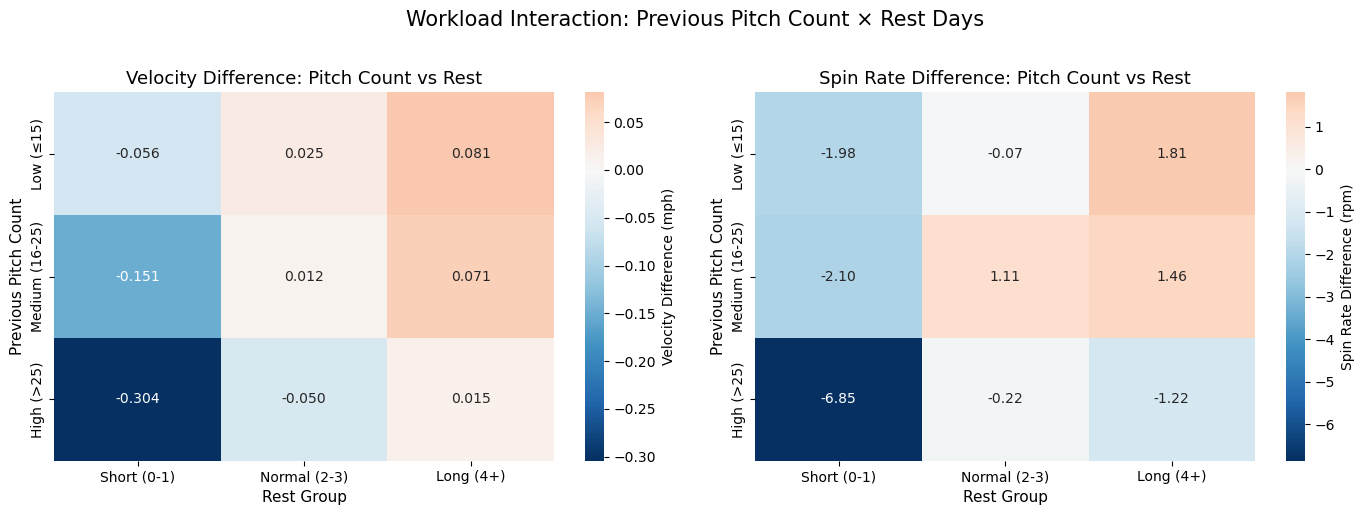

In [9]:
# Heatmaps: Velocity and Spin Rate difference by pitch count and rest days
import seaborn as sns
import matplotlib.pyplot as plt

pivot_velo = (pitch_count_summary
    .select(['prev_pitch_group', 'rest_group', 'mean_velo_diff'])
    .to_pandas()
    .pivot(index='prev_pitch_group', columns='rest_group', values='mean_velo_diff')
    [['Short (0-1)', 'Normal (2-3)', 'Long (4+)']]
)
pivot_velo = pivot_velo.loc[['Low (≤15)', 'Medium (16-25)', 'High (>25)']]

pivot_spin = (pitch_count_summary
    .select(['prev_pitch_group', 'rest_group', 'mean_spin_diff'])
    .to_pandas()
    .pivot(index='prev_pitch_group', columns='rest_group', values='mean_spin_diff')
    [['Short (0-1)', 'Normal (2-3)', 'Long (4+)']]
)
pivot_spin = pivot_spin.loc[['Low (≤15)', 'Medium (16-25)', 'High (>25)']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Velocity heatmap
sns.heatmap(pivot_velo, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            ax=ax1, cbar_kws={'label': 'Velocity Difference (mph)'})
ax1.set_title('Velocity Difference: Pitch Count vs Rest', fontsize=13)
ax1.set_xlabel('Rest Group', fontsize=11)
ax1.set_ylabel('Previous Pitch Count', fontsize=11)

# Spin rate heatmap
sns.heatmap(pivot_spin, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            ax=ax2, cbar_kws={'label': 'Spin Rate Difference (rpm)'})
ax2.set_title('Spin Rate Difference: Pitch Count vs Rest', fontsize=13)
ax2.set_xlabel('Rest Group', fontsize=11)
ax2.set_ylabel('Previous Pitch Count', fontsize=11)

fig.suptitle('Workload Interaction: Previous Pitch Count × Rest Days', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Filter to Short rest only (0-1 days)
short_rest_only = outing_with_groups.filter(pl.col('rest_group') == 'Short (0-1)')

# Get velocity for High vs Low pitch count groups
high_short = short_rest_only.filter(pl.col('prev_pitch_group') == 'High (>25)')['velo_deviation'].to_numpy()
low_short = short_rest_only.filter(pl.col('prev_pitch_group') == 'Low (≤15)')['velo_deviation'].to_numpy()

# T-test
t_stat, p_value = stats.ttest_ind(high_short, low_short)

print("INTERACTION EFFECT TEST: High vs Low Pitch Count on Short Rest")
print(f"\nHigh pitch count + Short rest:")
print(f"  Mean: {high_short.mean():.4f} mph")
print(f"  n = {len(high_short)}")

print(f"\nLow pitch count + Short rest:")
print(f"  Mean: {low_short.mean():.4f} mph")
print(f"  n = {len(low_short)}")

print(f"\nDifference: {high_short.mean() - low_short.mean():.4f} mph")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant: {p_value < 0.05}")

INTERACTION EFFECT TEST: High vs Low Pitch Count on Short Rest

High pitch count + Short rest:
  Mean: -0.3041 mph
  n = 324

Low pitch count + Short rest:
  Mean: -0.0555 mph
  n = 4185

Difference: -0.2486 mph
t-statistic: -4.615
p-value: 0.0000
Significant: True


### Interaction Test: High Pitch Count + Short Rest
Statistical significance of the workload × rest interaction

In [36]:
outing_table = pl.read_parquet('data/outing_table.parquet')
outing_table.head(3)

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124


## Individual Insights

In [12]:
# Calculate 7, 14, and 21-day rolling workloads
(outing_with_workload := (outing_table
    .filter(pl.col('rest_days') <= 10)
    .sort(['pitcher_id', 'date'])
    .with_columns([
        pl.col('pitch_count').rolling_sum_by('date', window_size='7d', closed='left').over('pitcher_id').alias('pitches_prev_7d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='14d', closed='left').over('pitcher_id').alias('pitches_prev_14d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='21d', closed='left').over('pitcher_id').alias('pitches_prev_21d')
    ])
    .with_columns([
        pl.when(pl.col('pitches_prev_7d') >= 60).then(pl.lit('High'))
          .when(pl.col('pitches_prev_7d') <= 30).then(pl.lit('Low'))
          .otherwise(pl.lit('Medium')).alias('workload_7d'),
        
        pl.when(pl.col('pitches_prev_14d') >= 120).then(pl.lit('High'))
          .when(pl.col('pitches_prev_14d') <= 60).then(pl.lit('Low'))
          .otherwise(pl.lit('Medium')).alias('workload_14d'),
        
        pl.when(pl.col('pitches_prev_21d') >= 180).then(pl.lit('High'))
          .when(pl.col('pitches_prev_21d') <= 90).then(pl.lit('Low'))
          .otherwise(pl.lit('Medium')).alias('workload_21d')
    ])
))

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_prev_7d,pitches_prev_14d,pitches_prev_21d,workload_7d,workload_14d,workload_21d
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,str,str,str
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,null,null,null,"""Medium""","""Medium""","""Medium"""
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,"""Low""","""Low""","""Low"""
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124,26,26,26,"""Low""","""Low""","""Low"""
433589,632231,2021-04-12 00:00:00,2021,"""Yusmeiro Petit""",7,86.357143,87.7,2242.0,-0.18,1.548571,6,"""R""",3,3,10,8,86.615973,2137.198876,-0.25883,104.801124,34,34,34,"""Medium""","""Low""","""Low"""
433589,632206,2021-04-13 00:00:00,2021,"""Yusmeiro Petit""",4,86.7,88.3,2058.5,-0.0875,1.3625,7,"""R""",0,1,6,10,86.615973,2137.198876,0.084027,-78.698876,44,44,44,"""Medium""","""Low""","""Low"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,746985,2024-09-19 00:00:00,2024,"""Spencer Bivens""",32,94.1,97.5,2093.96875,-0.650938,0.590938,8,"""R""",-1,4,37,13,94.048879,1941.835625,0.051121,152.133125,44,44,116,"""Medium""","""Low""","""Medium"""
702352,746255,2024-09-21 00:00:00,2024,"""Spencer Bivens""",18,95.127778,97.2,2105.0,-0.842222,0.501667,7,"""R""",9,2,28,37,94.048879,1941.835625,1.078899,163.164375,50,81,153,"""Medium""","""Medium""","""Medium"""
702352,747150,2024-09-23 00:00:00,2024,"""Spencer Bivens""",14,94.907143,97.1,2092.5,-0.977857,0.445714,6,"""R""",3,2,21,28,94.048879,1941.835625,0.858264,150.664375,65,109,163,"""High""","""Medium""","""Medium"""


In [13]:
# 7-day: High vs Low workload within same pitcher
(pitchers_7d := (outing_with_workload
    .group_by(['pitcher_id', 'pitcher_name', 'workload_7d'])
    .agg([pl.col('velo_deviation').mean().alias('mean_velo_diff'), pl.len().alias('count')])
    .filter(pl.col('count') >= 5)
    .pivot(index=['pitcher_id', 'pitcher_name'], columns='workload_7d', values='mean_velo_diff')
    .drop_nulls(['High', 'Low'])
    .with_columns([(pl.col('High') - pl.col('Low')).alias('effect_7d')])
    .select(['pitcher_id', 'pitcher_name', 'effect_7d'])
))

pitcher_id,pitcher_name,effect_7d
i64,str,f64
628708,"""Yunior Marte""",0.096514
571946,"""Shelby Miller""",-0.618347
489446,"""Kirby Yates""",-0.26362
605194,"""Jharel Cotton""",-0.04589
656222,"""Jalen Beeks""",-1.430855
…,…,…
621052,"""Alex Reyes""",0.520949
669093,"""Jeremiah Estrada""",0.158077
664294,"""Dauri Moreta""",-0.396645


In [14]:
# 14-day: High vs Low workload within same pitcher
(pitchers_14d := (outing_with_workload
    .group_by(['pitcher_id', 'pitcher_name', 'workload_14d'])
    .agg([pl.col('velo_deviation').mean().alias('mean_velo_diff'), pl.len().alias('count')])
    .filter(pl.col('count') >= 5)
    .pivot(index=['pitcher_id', 'pitcher_name'], columns='workload_14d', values='mean_velo_diff')
    .drop_nulls(['High', 'Low'])
    .with_columns([(pl.col('High') - pl.col('Low')).alias('effect_14d')])
    .select(['pitcher_id','effect_14d'])
))

pitcher_id,effect_14d
i64,f64
571882,-0.125891
676760,0.17661
664199,0.484039
592761,0.494963
668674,0.00336
…,…
622253,-1.159311
641703,0.006546
641360,0.127192


In [15]:
# 21-day: High vs Low workload within same pitcher
(pitchers_21d := (outing_with_workload
    .group_by(['pitcher_id', 'pitcher_name', 'workload_21d'])
    .agg([pl.col('velo_deviation').mean().alias('mean_velo_diff'), pl.len().alias('count')])
    .filter(pl.col('count') >= 5)
    .pivot(index=['pitcher_id', 'pitcher_name'], columns='workload_21d', values='mean_velo_diff')
    .drop_nulls(['High', 'Low'])
    .with_columns([(pl.col('High') - pl.col('Low')).alias('effect_21d')])
    .select(['pitcher_id', 'effect_21d'])
))

pitcher_id,effect_21d
i64,f64
642232,-0.623874
676395,0.639315
592761,0.570809
663986,0.458586
606930,-0.240943
…,…
608717,0.233205
448855,-0.140021
670950,0.526782


In [16]:
# Combine all three time windows
(pitchers_all_windows := (pitchers_7d
    .join(pitchers_14d, on='pitcher_id', how='inner')
    .join(pitchers_21d, on='pitcher_id', how='inner')
    .sort('effect_7d')
))

pitcher_id,pitcher_name,effect_7d,effect_14d,effect_21d
i64,str,f64,f64,f64
669211,"""Keegan Akin""",-0.409879,-0.270099,-0.091787
642232,"""Ryan Yarbrough""",-0.364905,-0.444982,-0.623874
502085,"""David Robertson""",-0.361606,-0.584448,-0.875254
650556,"""Bryan Abreu""",-0.345762,0.002215,0.105104
663546,"""Sean Hjelle""",-0.334583,-0.031862,-0.077739
…,…,…,…,…
641360,"""Phil Bickford""",0.27185,0.127192,0.046904
500610,"""Deolis Guerra""",0.377634,0.121712,0.306144
606930,"""Jacob Barnes""",0.40458,-0.402542,-0.240943


In [17]:
# Get mean velocity for each pitcher in Low and High workload periods (7-day)
(pitcher_slopes_7d := (pitchers_7d
    .join(
        outing_with_workload
        .filter(pl.col('workload_7d').is_in(['Low', 'High']))
        .group_by(['pitcher_id', 'workload_7d'])
        .agg([pl.col('velo_deviation').mean().alias('mean_velo')]),
        on='pitcher_id',
        how='left'
    )
    .pivot(index=['pitcher_id', 'pitcher_name'], columns='workload_7d', values='mean_velo')
    .drop_nulls()
    .to_pandas()
))

,pitcher_id,pitcher_name,High,Low
0,628708,Yunior Marte,0.188654,0.092141
1,571946,Shelby Miller,-0.595819,0.022527
2,489446,Kirby Yates,-0.265808,-0.002188
3,605194,Jharel Cotton,0.024849,0.070739
4,656222,Jalen Beeks,-1.044920,0.385935
...,...,...,...,...
216,621052,Alex Reyes,0.327447,-0.193502
217,669093,Jeremiah Estrada,-0.017581,-0.175657
218,664294,Dauri Moreta,-0.256016,0.140629
219,542888,Shawn Armstrong,0.826307,-0.287023


In [18]:
# Melt to long format for ggplot
pitcher_slopes_long = pd.melt(
    pitcher_slopes_7d,
    id_vars=['pitcher_id', 'pitcher_name'],
    value_vars=['Low', 'High'],
    var_name='workload',
    value_name='mean_velo'
)

# Set category order (Low first, then High)
pitcher_slopes_long['workload'] = pd.Categorical(
    pitcher_slopes_long['workload'],
    categories=['Low', 'High'],
    ordered=True
)

pitcher_slopes_long.head()

,pitcher_id,pitcher_name,workload,mean_velo
0,628708,Yunior Marte,Low,0.092141
1,571946,Shelby Miller,Low,0.022527
2,489446,Kirby Yates,Low,-0.002188
3,605194,Jharel Cotton,Low,0.070739
4,656222,Jalen Beeks,Low,0.385935


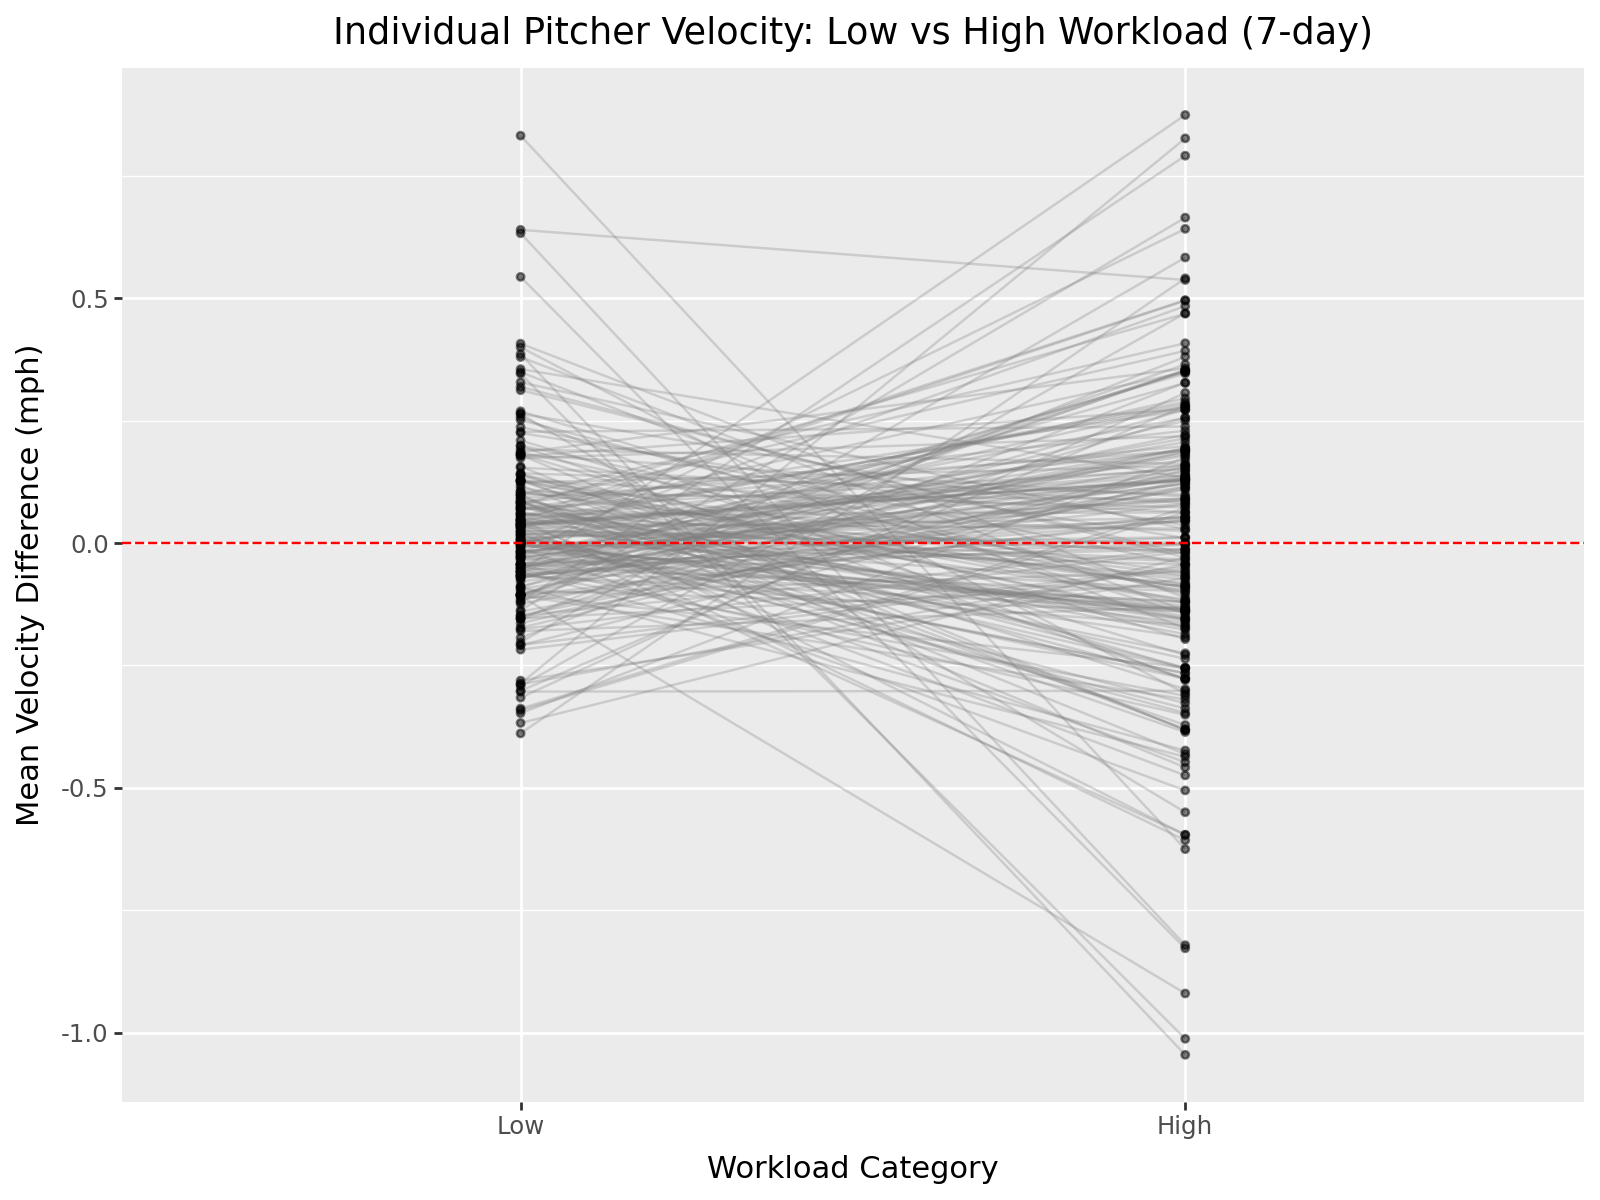

In [19]:
# Slope graph showing individual pitcher changes
(ggplot(pitcher_slopes_long, aes(x='workload', y='mean_velo', group='pitcher_name')) +
 geom_line(alpha=0.3, color='gray') +
 geom_point(alpha=0.5, size=1) +
 geom_hline(yintercept=0, linetype='dashed', color='red') +
 labs(title='Individual Pitcher Velocity: Low vs High Workload (7-day)',
      x='Workload Category',
      y='Mean Velocity Difference (mph)') +
 theme(figure_size=(8, 6)))

### Within-Pitcher Workload Effects (7/14/21 Day Windows)
Comparing same pitcher under High vs Low cumulative workload

In [20]:
# Top 10 most negatively affected by high workload
print("MOST AFFECTED BY HIGH WORKLOAD (Biggest velocity drops):")
pitchers_7d.sort('effect_7d').select(['pitcher_name', 'effect_7d']).head(10)

MOST AFFECTED BY HIGH WORKLOAD (Biggest velocity drops):


pitcher_name,effect_7d
str,f64
"""Calvin Faucher""",-1.456789
"""Reed Garrett""",-1.453636
"""Jalen Beeks""",-1.430855
"""Carmen Mlodzinski""",-1.37091
"""Ryan Fernandez""",-1.357954
"""Yennier Cano""",-0.813495
"""Jake Cousins""",-0.81129
"""Joey Wentz""",-0.707048
"""Tim Hill""",-0.683612


In [21]:
# Top 10 most resilient to high workload
print("\nMOST RESILIENT TO HIGH WORKLOAD (Maintain or gain velocity):")
pitchers_7d.sort('effect_7d', descending=True).select(['pitcher_name', 'effect_7d']).head(10)


MOST RESILIENT TO HIGH WORKLOAD (Maintain or gain velocity):


pitcher_name,effect_7d
str,f64
"""Shawn Armstrong""",1.11333
"""Seth Lugo""",0.931783
"""Anthony Banda""",0.929251
"""Zach Jackson""",0.911099
"""Cade Smith""",0.801389
"""Tyler Alexander""",0.785793
"""Tanner Rainey""",0.761252
"""Tim Mayza""",0.663822
"""Camilo Doval""",0.622349


In [22]:
# Count how many pitchers go up vs down (7-day workload)
(pitchers_direction := (pitchers_7d
    .with_columns([
        pl.when(pl.col('effect_7d') < 0)
          .then(pl.lit('Slower when tired'))
          .when(pl.col('effect_7d') > 0)
          .then(pl.lit('Faster when tired'))
          .otherwise(pl.lit('No change'))
          .alias('direction')
    ])
    .group_by('direction')
    .agg([pl.len().alias('count')])
))

direction,count
str,u32
"""Slower when tired""",109
"""Faster when tired""",112


In [23]:

workload_effects_7d = pitchers_7d['effect_7d'].to_numpy()
# One-sample t-test (testing if mean effect is different from 0)
t_stat, p_value = stats.ttest_1samp(workload_effects_7d, 0)

print("7-Day Workload Effect Test")
print(f"Mean effect: {workload_effects_7d.mean():.4f} mph")
print(f"Median effect: {np.median(workload_effects_7d):.4f} mph")
print(f"Std dev: {workload_effects_7d.std():.4f} mph")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant at 0.05: {p_value < 0.05}")
print(f"n = {len(workload_effects_7d)} pitchers")

7-Day Workload Effect Test
Mean effect: -0.0243 mph
Median effect: 0.0037 mph
Std dev: 0.3965 mph
t-statistic: -0.910
p-value: 0.3638
Significant at 0.05: False
n = 221 pitchers


#### Velocity by day is significant however workload is not significant

## Relates to Heat Map up top. Looking at previous outing pitch count and avg fb velo comparison

In [24]:
# Velocity by exact previous pitch count (binned by 5)
(pitch_count_gradient := (outing_table
    .filter((pl.col('rest_days') <= 3) & (pl.col('prev_pitch_count') <= 40))
    .with_columns([
        (pl.col('prev_pitch_count') // 5 * 5).alias('pitch_bin')
    ])
    .group_by('pitch_bin')
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo'),
        pl.len().alias('n')
    ])
    .filter(pl.col('n') >= 50)
    .sort('pitch_bin')
    .to_pandas()
))

# Plot it

,pitch_bin,mean_velo,n
0,0,-0.014230,649
1,5,0.033125,3287
2,10,-0.003613,7780
3,15,-0.030584,7027
4,20,-0.024930,3978
5,25,-0.066022,2018
6,30,-0.098652,867
7,35,-0.027384,323


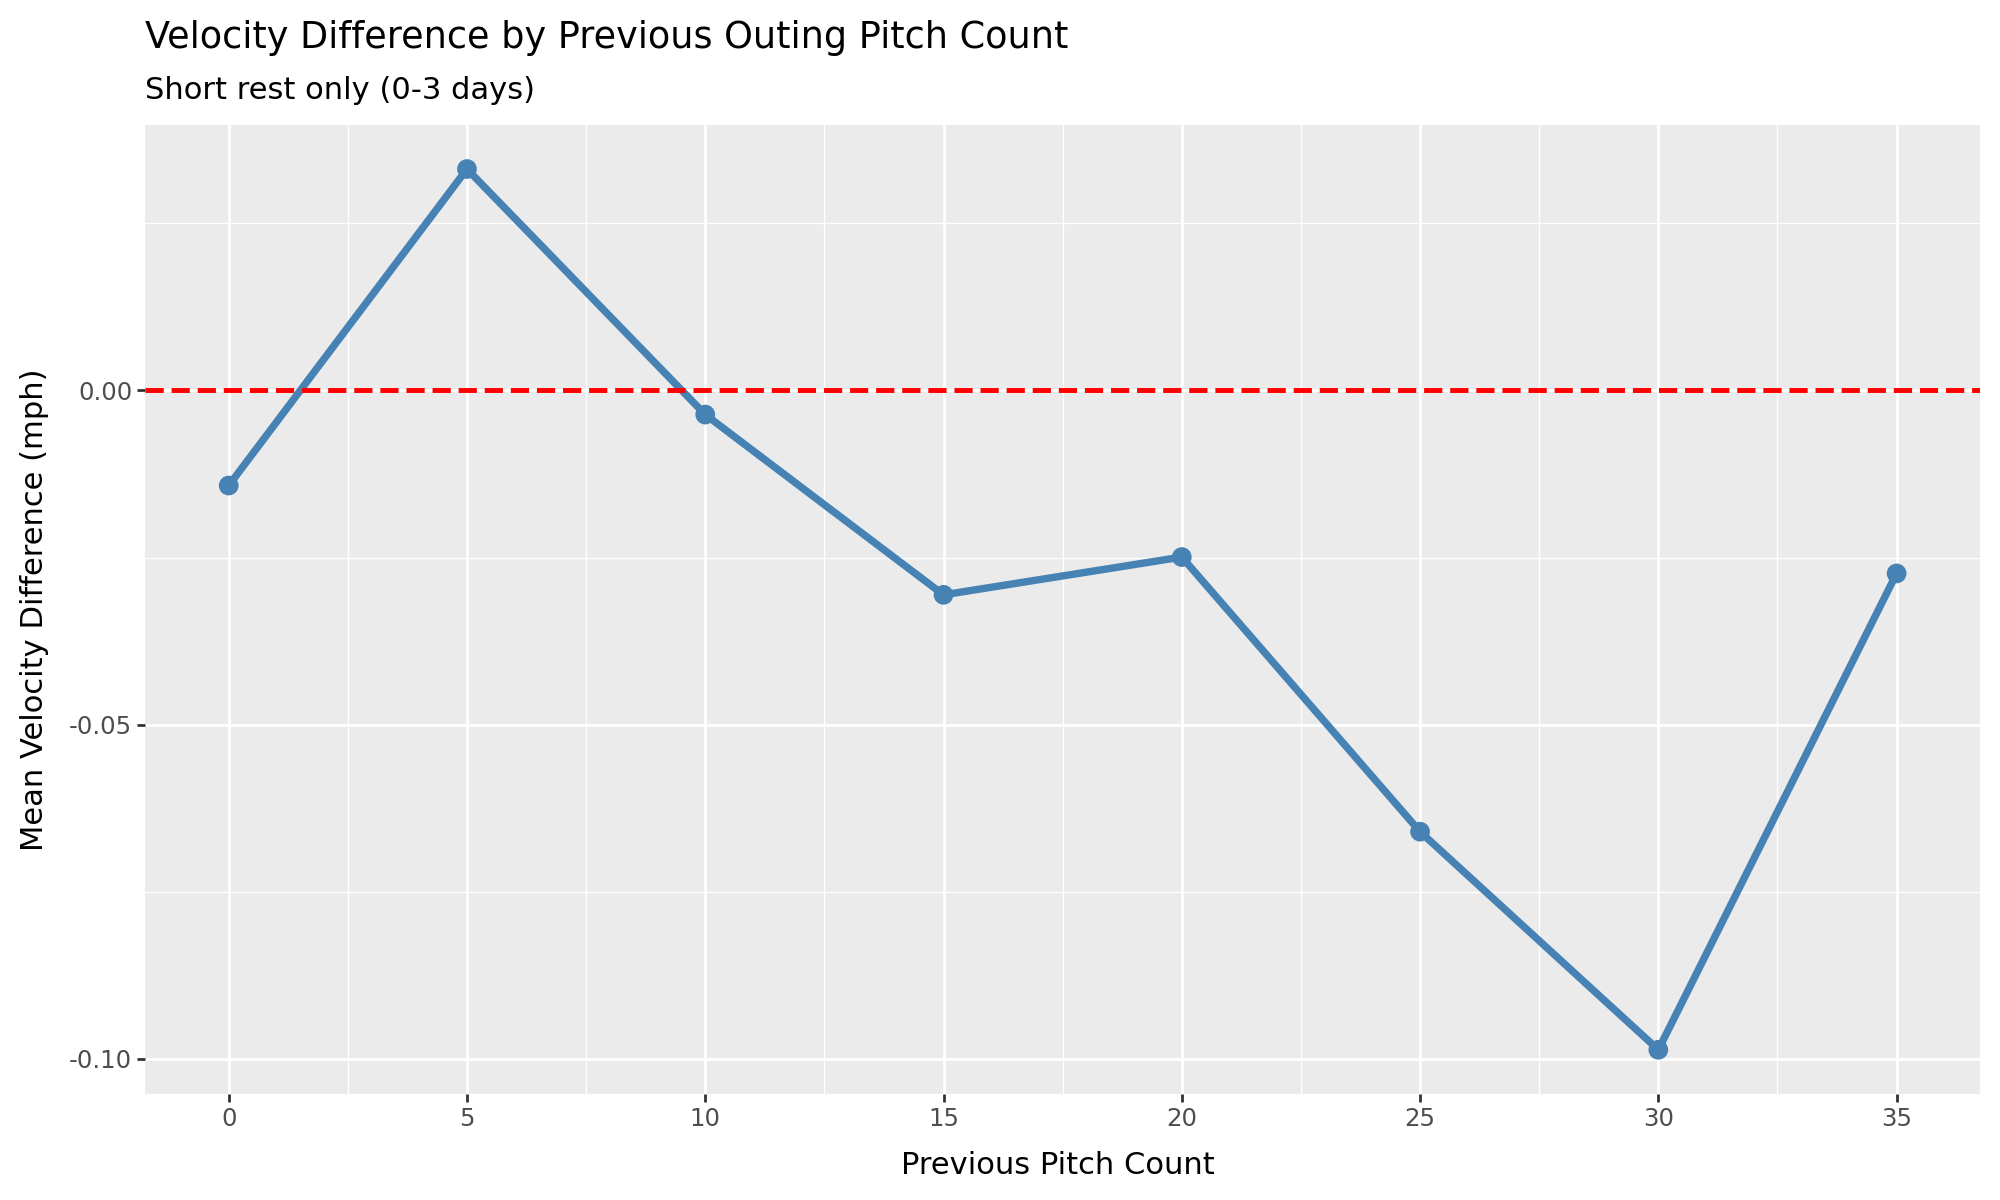

In [25]:
(ggplot(pitch_count_gradient, aes(x='pitch_bin', y='mean_velo')) +
 geom_line(color='steelblue', size=1.5) +
 geom_point(color='steelblue', size=3) +
 geom_hline(yintercept=0, linetype='dashed', color='red', size=1) +
 labs(title='Velocity Difference by Previous Outing Pitch Count',
      subtitle='Short rest only (0-3 days)',
      x='Previous Pitch Count ',
      y='Mean Velocity Difference (mph)') +
 scale_x_continuous(breaks=range(0, 45, 5)) +
 theme(figure_size=(10, 6)))

## High level situations

In [26]:
# Does rest matter more for late-inning/high-leverage pitchers?
(rest_by_inning := (outing_table
    .filter(pl.col('rest_days') <= 10)
    .with_columns([
        pl.when(pl.col('inning_entered') >= 7)
          .then(pl.lit('Late (7-9)'))
          .otherwise(pl.lit('Early (1-6)'))
          .alias('inning_group')
    ])
    .group_by(['rest_days', 'inning_group'])
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo'),
        pl.col('velo_deviation').std().alias('std_velo'),
        pl.len().alias('n')
    ])
    .filter(pl.col('n') >= 30)
    .with_columns([
        (pl.col('std_velo') / pl.col('n').sqrt()).alias('se')
    ])
    .sort(['inning_group', 'rest_days'])
    .to_pandas()
)).head()

,rest_days,inning_group,mean_velo,std_velo,n,se
0,1,Early (1-6),-0.216138,0.911303,972,0.029230
1,2,Early (1-6),-0.116789,0.903379,2183,0.019335
2,3,Early (1-6),-0.089155,0.900210,1868,0.020828
3,4,Early (1-6),-0.040157,0.923544,1084,0.028051
4,5,Early (1-6),-0.033140,0.860666,503,0.038375


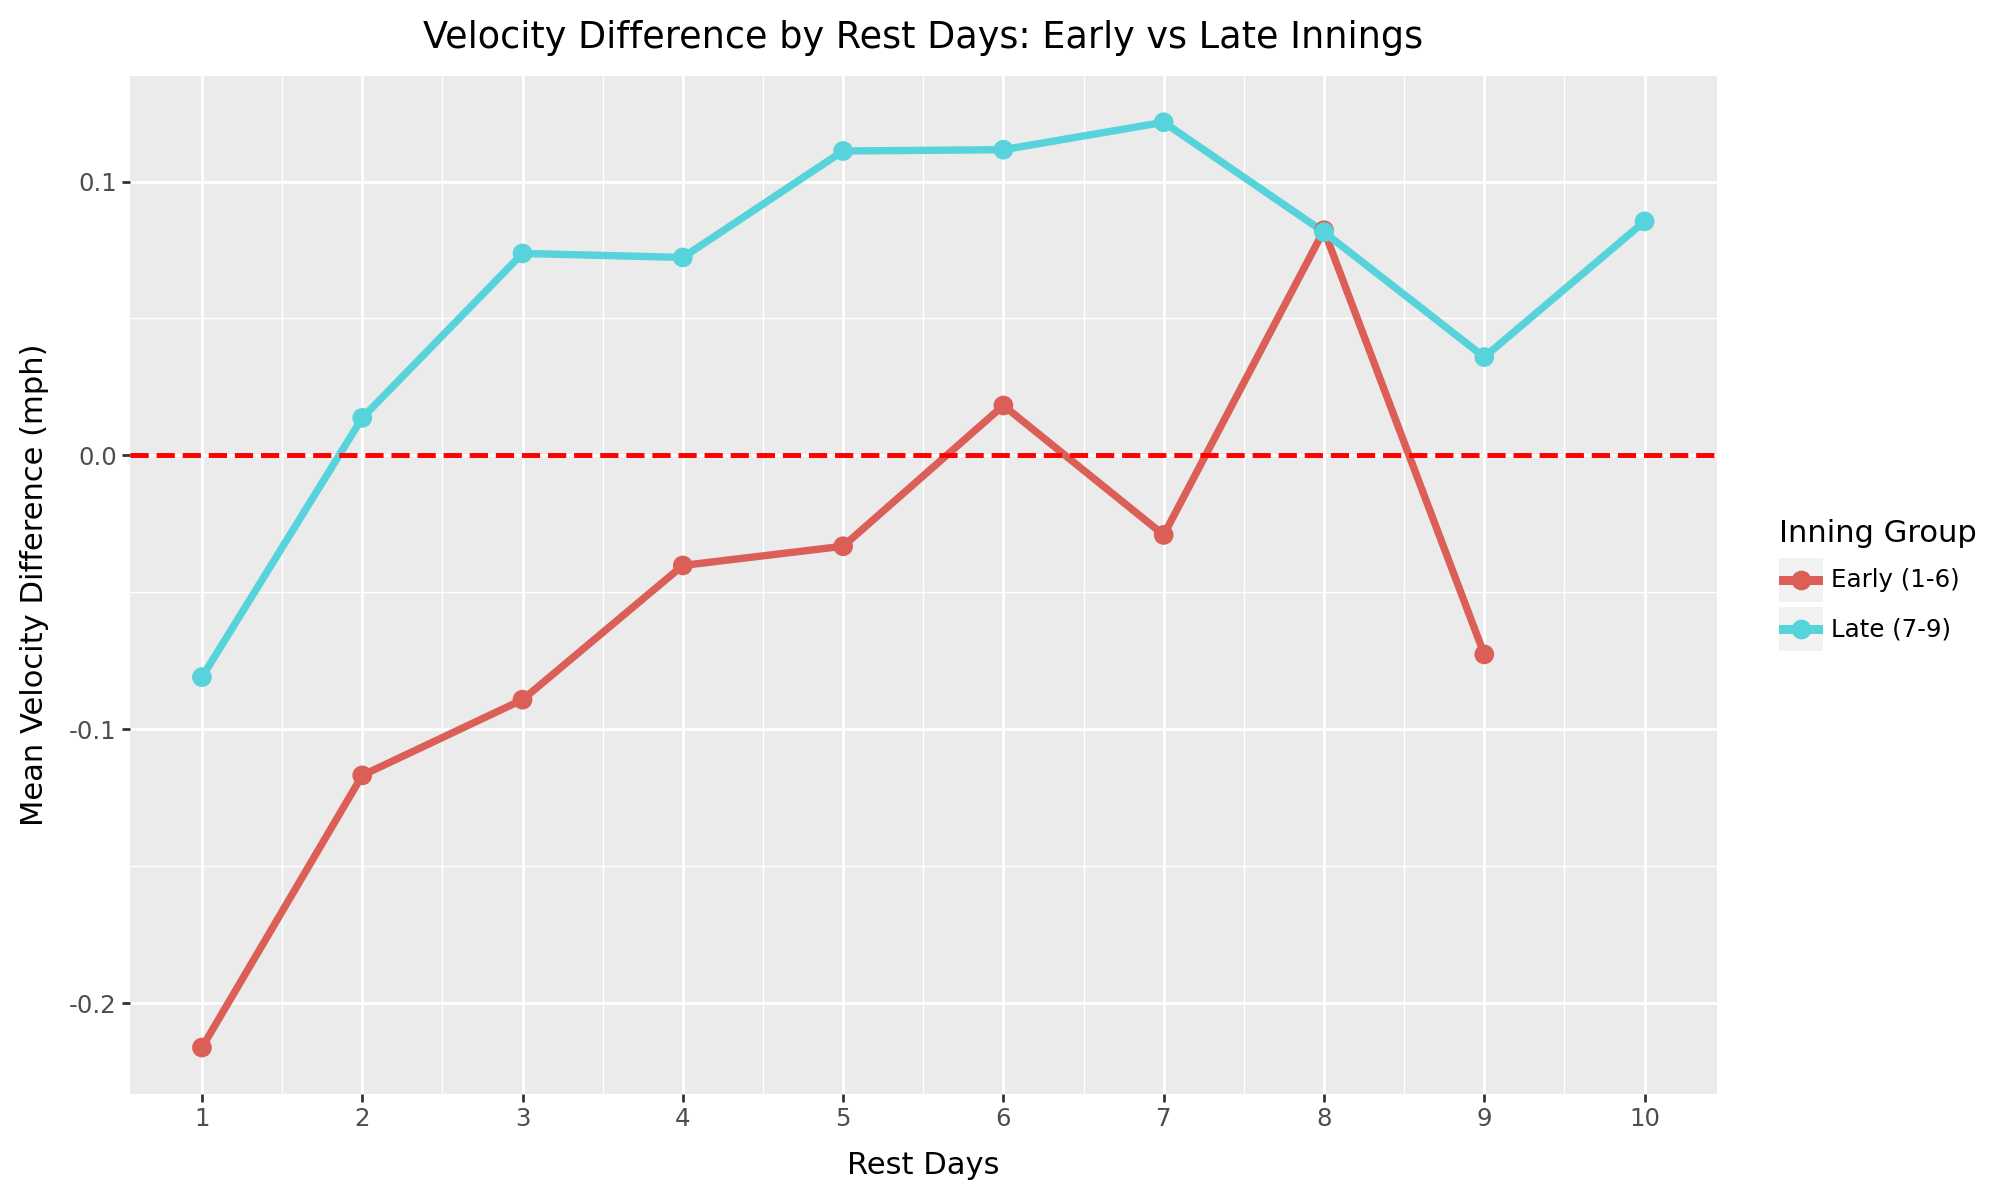

In [27]:
(ggplot(rest_by_inning, aes(x='rest_days', y='mean_velo', color='inning_group')) +
 geom_line(size=1.5) +
 geom_point(size=3) +
 geom_hline(yintercept=0, linetype='dashed', color='red', size=1) +
 labs(title='Velocity Difference by Rest Days: Early vs Late Innings',
      x='Rest Days',
      y='Mean Velocity Difference (mph)',
      color='Inning Group') +
 scale_x_continuous(breaks=range(0, 11)) +
 theme(figure_size=(10, 6)))

###### High-leverage pitchers (closers) are either more resilient OR teams simply don't care about rest when it's a save situation — they use their best arm no matter what. The rest-day effect shows up more clearly in lower-leverage situations where managers have more flexibility

## More individual things

In [28]:
# Calculate each pitcher's rest sensitivity (1 day vs 3 days difference)
(pitcher_rest_sensitivity := (outing_table
    .filter(pl.col('rest_days').is_in([1, 3]))
    .group_by(['pitcher_id', 'pitcher_name', 'rest_days'])
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo_diff'),
        pl.len().alias('n')
    ])
    .filter(pl.col('n') >= 3)
    .pivot(index=['pitcher_id', 'pitcher_name'], columns='rest_days', values='mean_velo_diff')
    .drop_nulls()
    .with_columns([
        (pl.col('3') - pl.col('1')).alias('rest_sensitivity')
    ])
))

# Get each pitcher's average fastball velocity (actual mph, not deviation)
(pitcher_avg_velo := (outing_table
    .group_by(['pitcher_id', 'pitcher_name'])
    .agg([
        pl.col('mean_fb_velocity').mean().alias('avg_fb_velo')
    ])
))

# Join them together
(pitcher_scatter_data := (pitcher_rest_sensitivity
    .join(pitcher_avg_velo, on=['pitcher_id', 'pitcher_name'], how='inner')
    .select(['pitcher_name', 'avg_fb_velo', 'rest_sensitivity'])
    .to_pandas()
))

,pitcher_name,avg_fb_velo,rest_sensitivity
0,Andrew Nardi,94.345988,0.610230
1,Sam Coonrod,97.976123,0.443659
2,Chris Devenski,93.873471,-0.041420
3,Joe Smith,86.285290,-0.072368
4,Austin Voth,92.019570,0.426532
...,...,...,...
352,Miguel Castro,97.343158,0.068745
353,Alex Reyes,96.630623,0.538247
354,Tyler Matzek,95.272496,-0.145363
355,Jake Brentz,96.783560,0.244741


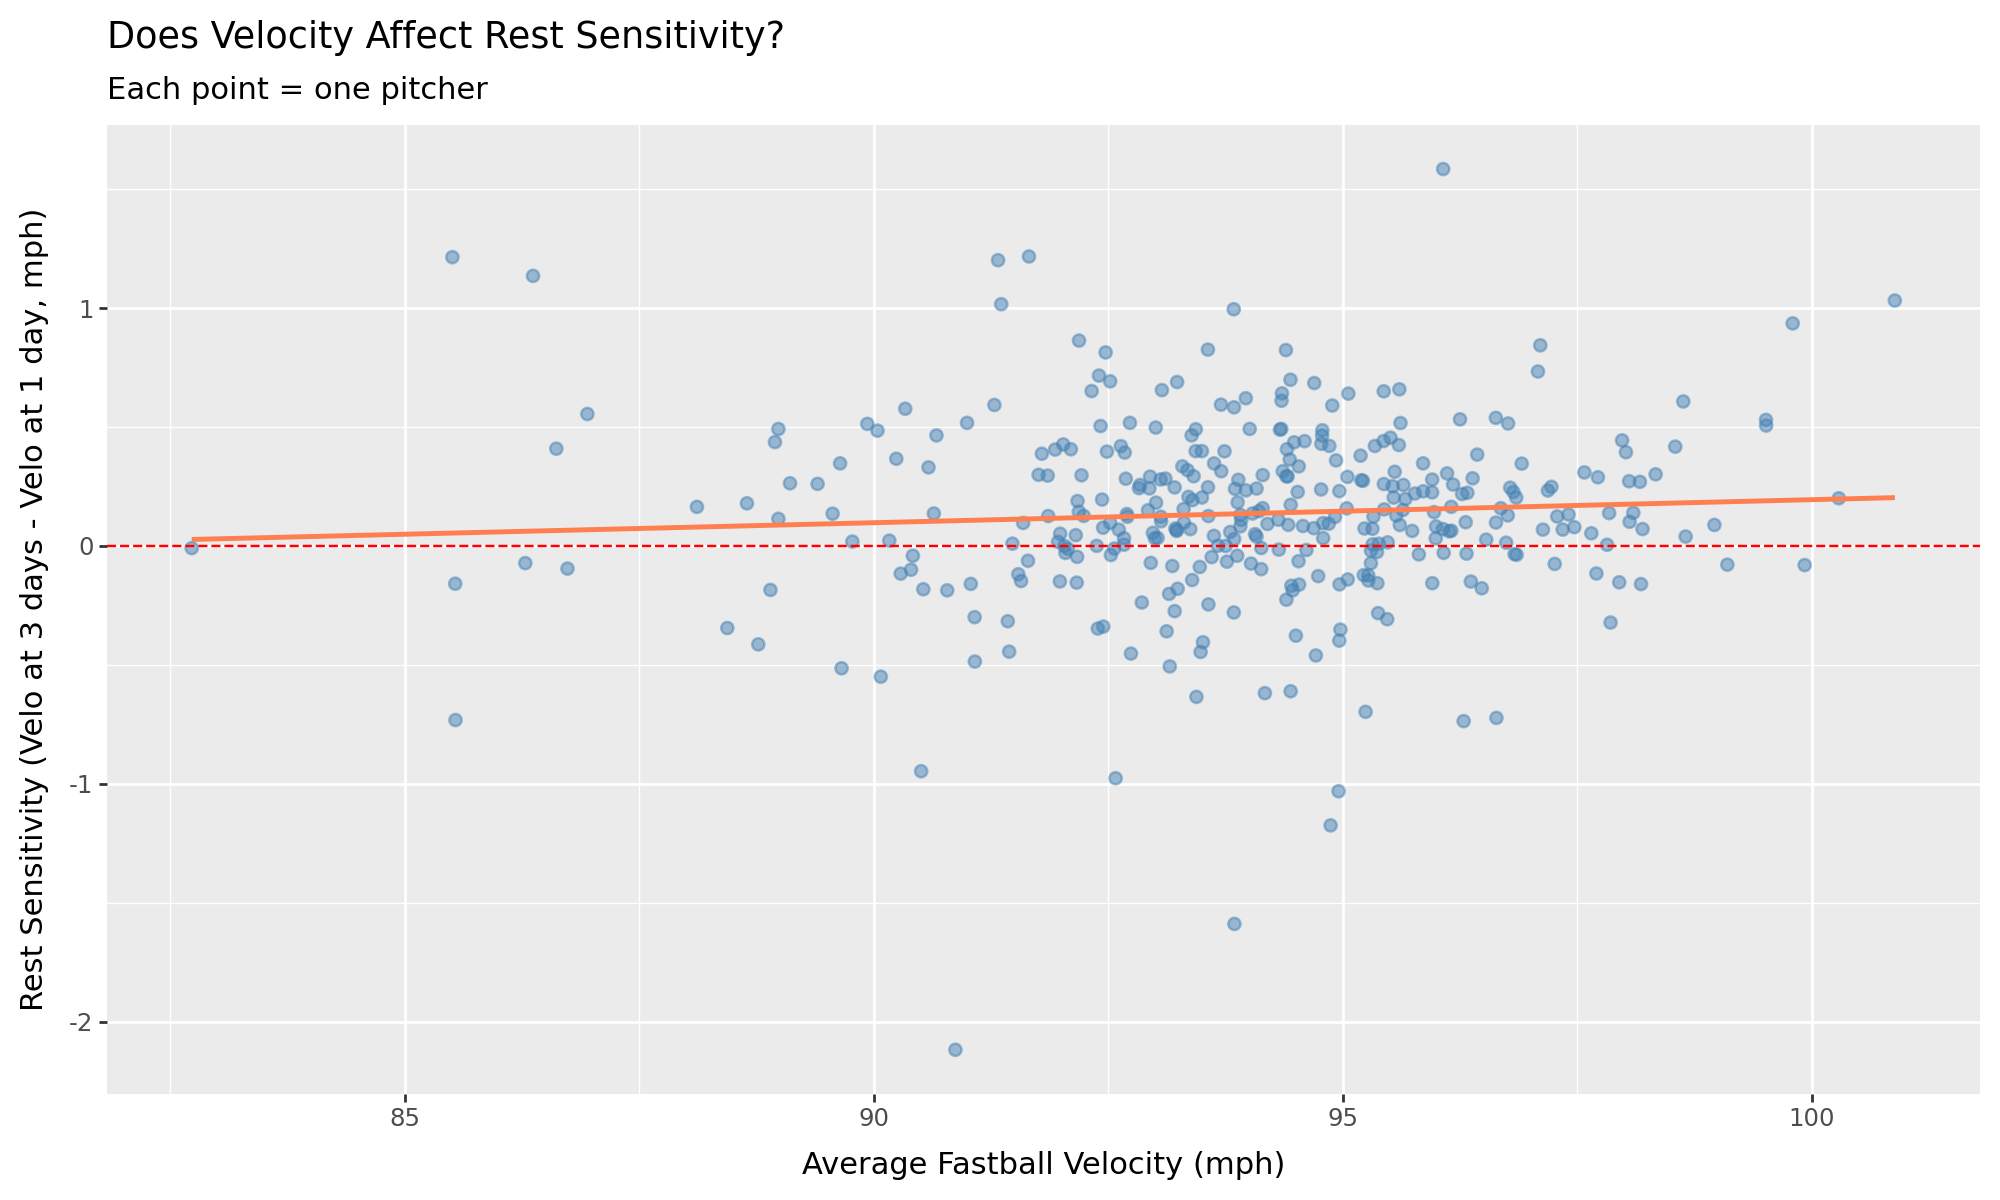

In [29]:
# Scatter: Average velocity vs rest sensitivity

(ggplot(pitcher_scatter_data, aes(x='avg_fb_velo', y='rest_sensitivity')) +
 geom_point(alpha=0.5, size=2, color='steelblue') +
 geom_hline(yintercept=0, linetype='dashed', color='red') +
 geom_smooth(method='lm', color='coral', se=False) +
 labs(title='Does Velocity Affect Rest Sensitivity?',
      subtitle='Each point = one pitcher',
      x='Average Fastball Velocity (mph)',
      y='Rest Sensitivity (Velo at 3 days - Velo at 1 day, mph)') +
 theme(figure_size=(10, 6)))

##### Interpretation: Average velocity does NOT predict rest sensitivity. Hard throwers (95-100 mph) and softer throwers (88-92 mph) both show similar variability in how they respond to rest. This is purely individual, not velocity-dependent.
The trendline being slightly above zero means most pitchers DO improve from 1→3 rest days (which matches your earlier finding), but velocity tier doesn't predict who improves more.
Conclusion: Keep this plot — it rules out velocity as a moderator of the rest effect. Rest sensitivity is individual, not related to how hard you throw.

## Individual Pitcher Rest-Velocity Response

Estimating pitcher-specific slopes to show heterogeneity in rest effects

In [30]:
# Calculate per-pitcher rest-day slopes
# For each pitcher, fit a linear model: velo_deviation ~ rest_days
# Extract the slope (beta coefficient for rest_days)

from sklearn.linear_model import LinearRegression

# Filter to rest days 0-5 (clearest signal) and pitchers with enough data
pitcher_rest_data = (outing_table
    .filter((pl.col('rest_days') >= 0) & (pl.col('rest_days') <= 5))
    .group_by('pitcher_id')
    .agg([
        pl.col('pitcher_name').first(),
        pl.len().alias('n_outings')
    ])
    .filter(pl.col('n_outings') >= 20)  # At least 20 outings for reliable estimate
)

# Function to calculate slope for one pitcher
def get_pitcher_slope(pitcher_data):
    X = pitcher_data['rest_days'].to_numpy().reshape(-1, 1)
    y = pitcher_data['velo_deviation'].to_numpy()
    
    if len(X) < 10:  # Skip if too few observations
        return None
    
    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0]  # Slope

# Calculate slopes for all pitchers
pitcher_slopes = []
for row in pitcher_rest_data.iter_rows(named=True):
    pitcher_id = row['pitcher_id']
    pitcher_name = row['pitcher_name']
    
    # Get data for this pitcher
    pitcher_data = (outing_table
        .filter((pl.col('pitcher_id') == pitcher_id) & 
                (pl.col('rest_days') >= 0) & 
                (pl.col('rest_days') <= 5))
        .select(['rest_days', 'velo_deviation'])
        .to_pandas()
    )
    
    slope = get_pitcher_slope(pitcher_data)
    if slope is not None:
        pitcher_slopes.append({
            'pitcher_id': pitcher_id,
            'pitcher_name': pitcher_name,
            'rest_velo_slope': slope
        })

# Convert to DataFrame
pitcher_slopes_df = pd.DataFrame(pitcher_slopes)

print(f"Analyzed {len(pitcher_slopes_df)} pitchers")
print(f"\nSlope distribution:")
print(pitcher_slopes_df['rest_velo_slope'].describe())
print(f"\n% with POSITIVE slope (velocity increases with rest): {(pitcher_slopes_df['rest_velo_slope'] > 0).mean() * 100:.1f}%")
print(f"% with NEGATIVE slope (velocity decreases with rest): {(pitcher_slopes_df['rest_velo_slope'] < 0).mean() * 100:.1f}%")

Analyzed 378 pitchers

Slope distribution:
count    378.000000
mean       0.042252
std        0.125811
min       -0.671940
25%       -0.006097
50%        0.049327
75%        0.099018
max        0.416441
Name: rest_velo_slope, dtype: float64

% with POSITIVE slope (velocity increases with rest): 72.2%
% with NEGATIVE slope (velocity decreases with rest): 27.8%


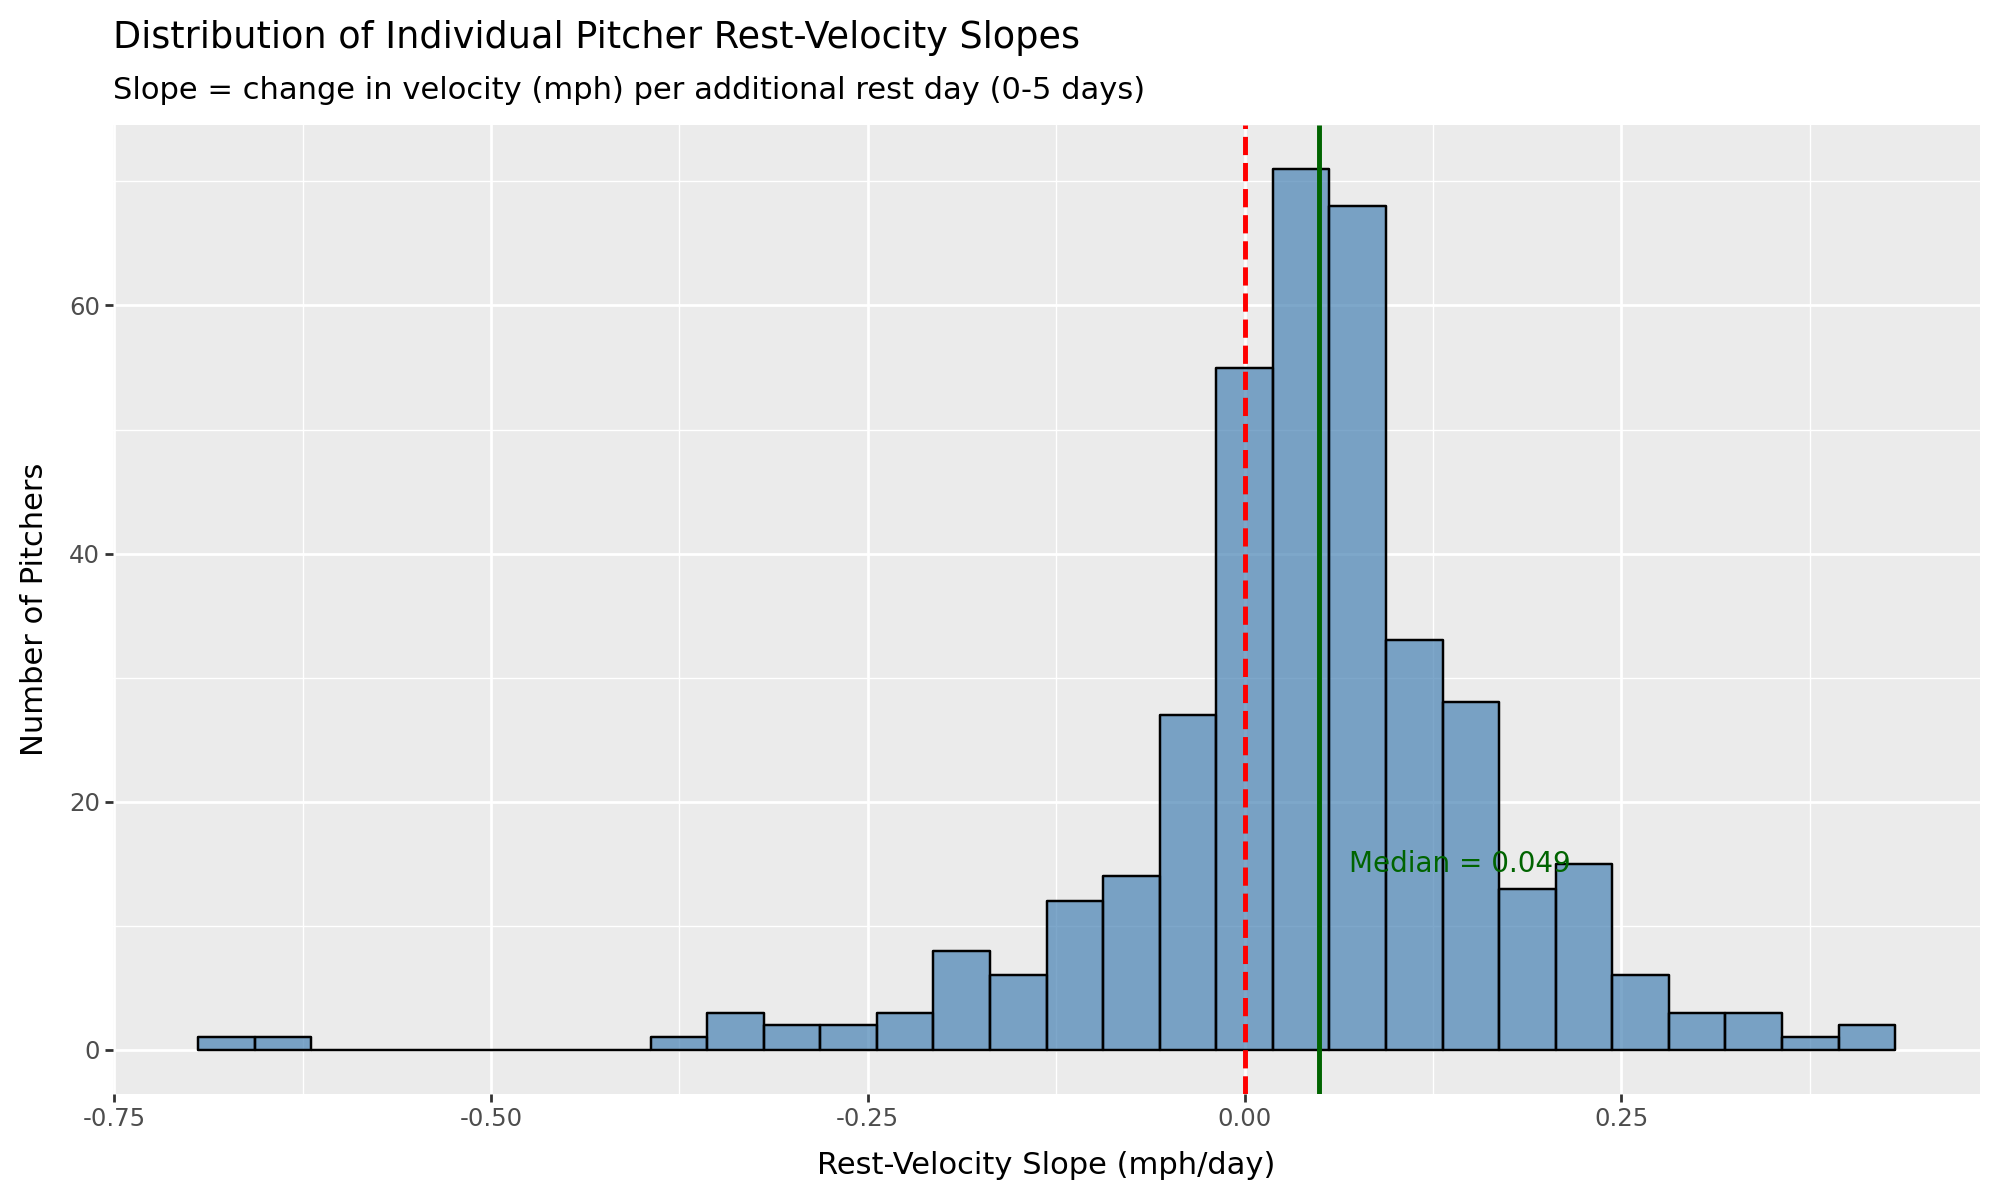

In [31]:
# Visualize distribution of individual pitcher slopes
median_slope = pitcher_slopes_df['rest_velo_slope'].median()

(ggplot(pitcher_slopes_df, aes(x='rest_velo_slope')) +
 geom_histogram(bins=30, fill='steelblue', alpha=0.7, color='black') +
 geom_vline(xintercept=0, linetype='dashed', color='red', size=1) +
 geom_vline(xintercept=median_slope, linetype='solid', color='darkgreen', size=1) +
 annotate('text', x=median_slope+0.02, y=15, 
          label=f'Median = {median_slope:.3f}', 
          color='darkgreen', ha='left', size=10) +
 labs(title='Distribution of Individual Pitcher Rest-Velocity Slopes',
      subtitle='Slope = change in velocity (mph) per additional rest day (0-5 days)',
      x='Rest-Velocity Slope (mph/day)',
      y='Number of Pitchers') +
 theme(figure_size=(10, 6)))

##### Key Finding: While additional rest days are associated with increased fastball velocity on average, individual pitcher responses vary substantially.

The distribution shows:
- Most pitchers (shown by median and histogram shape) do benefit from additional rest
- However, there's considerable heterogeneity - some pitchers show strong positive responses while others show minimal or even negative responses
- This suggests that rest management should be personalized rather than applying a one-size-fits-all approach

## Pitcher Grouping Analysis: High-Usage vs Low-Usage Relievers

Testing whether the rest-velocity relationship differs between pitchers used frequently vs sparingly

In [32]:
# Classify pitchers by usage level (appearances per season)
# Calculate total appearances per pitcher per season
pitcher_usage = (outing_table
    .group_by(['pitcher_id', 'pitcher_name', 'year'])
    .agg([
        pl.len().alias('appearances')
    ])
    .group_by(['pitcher_id', 'pitcher_name'])
    .agg([
        pl.col('appearances').mean().alias('avg_appearances_per_season')
    ])
)

# Define usage groups based on median split
median_usage = pitcher_usage['avg_appearances_per_season'].median()
print(f"Median appearances per season: {median_usage:.1f}")

pitcher_usage = pitcher_usage.with_columns([
    pl.when(pl.col('avg_appearances_per_season') >= median_usage)
      .then(pl.lit('High Usage'))
      .otherwise(pl.lit('Low Usage'))
      .alias('usage_group')
])

print(f"\nHigh Usage: ≥{median_usage:.1f} appearances/season")
print(f"Low Usage: <{median_usage:.1f} appearances/season")
print(f"\nPitchers per group:")
print(pitcher_usage.group_by('usage_group').agg(pl.len()).sort('usage_group'))

Median appearances per season: 50.0

High Usage: ≥50.0 appearances/season
Low Usage: <50.0 appearances/season

Pitchers per group:
shape: (2, 2)
┌─────────────┬─────┐
│ usage_group ┆ len │
│ ---         ┆ --- │
│ str         ┆ u32 │
╞═════════════╪═════╡
│ High Usage  ┆ 208 │
│ Low Usage   ┆ 189 │
└─────────────┴─────┘


In [33]:
# Join usage groups with outing data
outing_with_usage = (outing_table
    .join(pitcher_usage.select(['pitcher_id', 'usage_group']), on='pitcher_id', how='left')
    .filter(pl.col('usage_group').is_not_null())  # Keep only classified pitchers
)

# Calculate rest-velocity relationship by usage group
usage_rest_effect = (outing_with_usage
    .filter(pl.col('rest_days') <= 10)
    .group_by(['usage_group', 'rest_days'])
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo'),
        pl.col('velo_deviation').std().alias('std_velo'),
        pl.len().alias('n')
    ])
    .with_columns([
        (pl.col('std_velo') / pl.col('n').sqrt()).alias('se')
    ])
    .sort(['usage_group', 'rest_days'])
    .to_pandas()
)

usage_rest_effect.head(10)

,usage_group,rest_days,mean_velo,std_velo,n,se
0,High Usage,0,-0.096732,0.836765,27,0.161035
1,High Usage,1,-0.100442,0.930837,5318,0.012764
2,High Usage,2,-0.009455,0.883397,7905,0.009936
3,High Usage,3,0.040390,0.919296,6013,0.011855
4,High Usage,4,0.047639,0.904819,3303,0.015744
5,High Usage,5,0.089376,0.890881,1728,0.021431
6,High Usage,6,0.088587,0.885077,834,0.030648
7,High Usage,7,0.097762,0.819550,405,0.040724
8,High Usage,8,0.036791,0.840533,200,0.059435
9,High Usage,9,0.124913,0.937892,85,0.101729


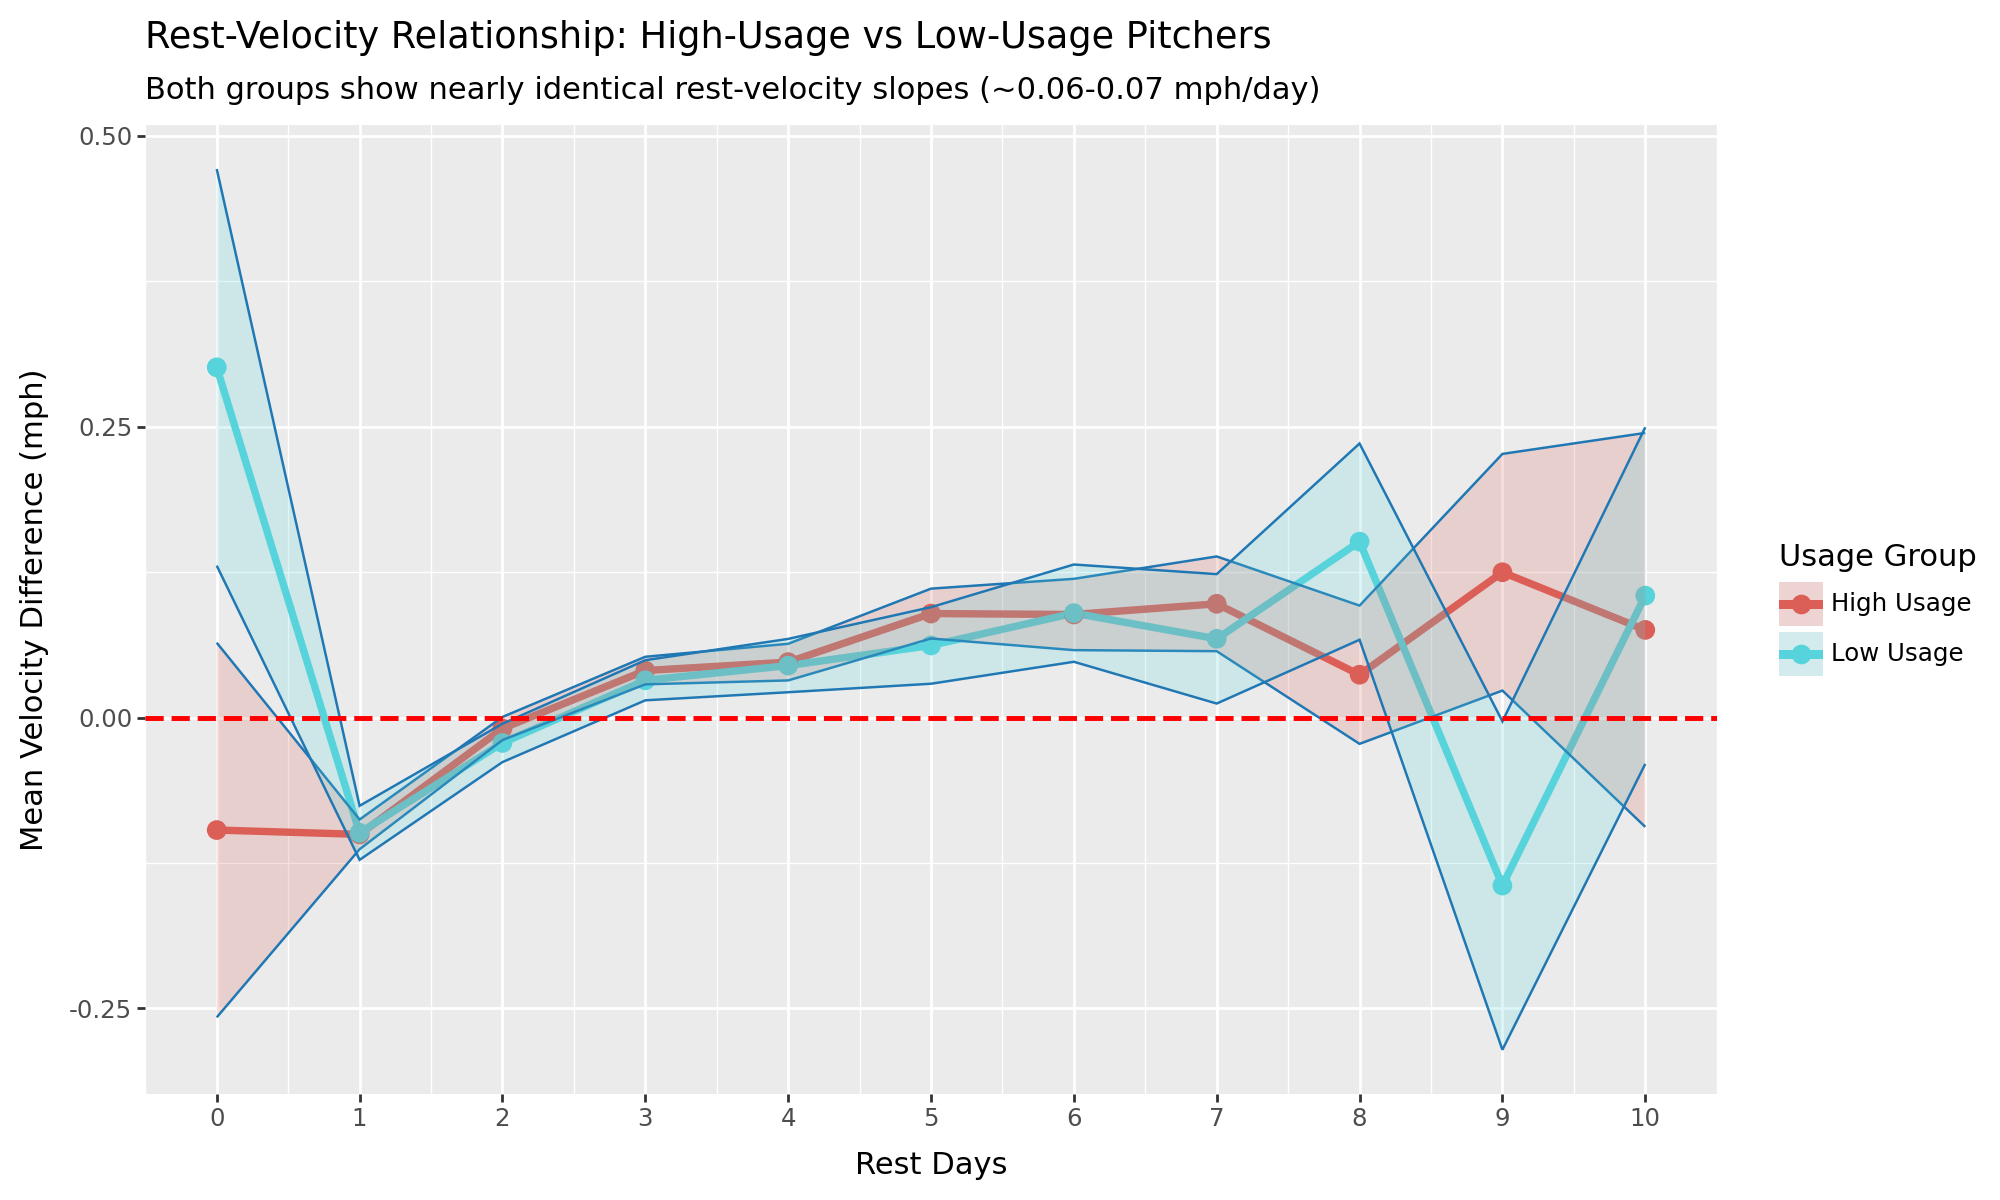

In [34]:
# Visualize rest-velocity relationship by usage group
(ggplot(usage_rest_effect, aes(x='rest_days', y='mean_velo', color='usage_group')) +
 geom_line(size=1.5) +
 geom_point(size=3) +
 geom_ribbon(aes(ymin='mean_velo - se', ymax='mean_velo + se', fill='usage_group'), 
             alpha=0.2, color=None) +
 geom_hline(yintercept=0, linetype='dashed', color='red', size=1) +
 labs(title='Rest-Velocity Relationship: High-Usage vs Low-Usage Pitchers',
      subtitle='Both groups show nearly identical rest-velocity slopes (~0.06-0.07 mph/day)',
      x='Rest Days',
      y='Mean Velocity Difference (mph)',
      color='Usage Group',
      fill='Usage Group') +
 scale_x_continuous(breaks=range(0, 11)) +
 theme(figure_size=(10, 6)))

In [35]:
# Test for interaction: Does usage level moderate the rest-velocity relationship?
# Compare slopes for high-usage vs low-usage pitchers

# Get data for each group at 0-3 rest days (clearest effect)
high_usage_data = outing_with_usage.filter(
    (pl.col('usage_group') == 'High Usage') & 
    (pl.col('rest_days') >= 0) & 
    (pl.col('rest_days') <= 3)
).to_pandas()

low_usage_data = outing_with_usage.filter(
    (pl.col('usage_group') == 'Low Usage') & 
    (pl.col('rest_days') >= 0) & 
    (pl.col('rest_days') <= 3)
).to_pandas()

# Fit linear models for each group
X_high = high_usage_data['rest_days'].values.reshape(-1, 1)
y_high = high_usage_data['velo_deviation'].values

X_low = low_usage_data['rest_days'].values.reshape(-1, 1)
y_low = low_usage_data['velo_deviation'].values

model_high = LinearRegression().fit(X_high, y_high)
model_low = LinearRegression().fit(X_low, y_low)

slope_high = model_high.coef_[0]
slope_low = model_low.coef_[0]

print("REST-VELOCITY SLOPES BY USAGE GROUP (0-3 rest days)")
print("=" * 60)
print(f"\nHigh Usage Pitchers:")
print(f"  Slope: {slope_high:.4f} mph per rest day")
print(f"  n = {len(high_usage_data):,} outings")

print(f"\nLow Usage Pitchers:")
print(f"  Slope: {slope_low:.4f} mph per rest day")
print(f"  n = {len(low_usage_data):,} outings")

print(f"\nDifference: {slope_high - slope_low:.4f} mph per rest day")
print(f"\nInterpretation:")
if abs(slope_high - slope_low) > 0.02:
    if slope_high > slope_low:
        print("  High-usage pitchers show a STRONGER benefit from rest")
    else:
        print("  Low-usage pitchers show a STRONGER benefit from rest")
else:
    print("  Both groups show SIMILAR rest-velocity relationships")

REST-VELOCITY SLOPES BY USAGE GROUP (0-3 rest days)

High Usage Pitchers:
  Slope: 0.0696 mph per rest day
  n = 19,263 outings

Low Usage Pitchers:
  Slope: 0.0634 mph per rest day
  n = 6,872 outings

Difference: 0.0062 mph per rest day

Interpretation:
  Both groups show SIMILAR rest-velocity relationships


##### Key Finding: Usage level does NOT meaningfully moderate the rest-velocity relationship. Both high-usage and low-usage pitchers show similar benefits from additional rest.

This grouping analysis reveals:
- **High-usage pitchers** show a slope of 0.0696 mph per rest day (n=19,263 outings)
- **Low-usage pitchers** show a slope of 0.0634 mph per rest day (n=6,872 outings)  
- **Difference**: Only 0.0062 mph per rest day - essentially negligible

**Interpretation**: The rest-velocity relationship is remarkably consistent across usage patterns. Whether a pitcher appears frequently or sparingly, they gain approximately 0.06-0.07 mph per additional rest day. This suggests that:
- Rest benefits are universal, not dependent on workload
- The recovery mechanism from rest is similar regardless of how often a pitcher is used
- Usage frequency alone cannot predict which pitchers will benefit most from additional rest

**Practical implication**: This null result actually strengthens the finding that rest effects are *individual* (as shown in the previous analysis), not explained by usage patterns, velocity levels, or situational factors. Teams should track individual pitcher responses rather than relying on group-level heuristics.

## Summary: Question 1 Key Findings

**Main Effects:**
- Velocity drops ~0.10 mph at 1 rest day, recovers by 2-3 days (p < 0.001)
- Spin rate follows similar pattern but NOT statistically significant

**Key Interaction:**
- High pitch count (>25) + Short rest (0-1 days) = -0.30 mph velocity drop
- This is 3x larger than rest-day-only effect (p < 0.0001)

**Individual Variability:**
- Cumulative 7-day workload shows no consistent average effect (p = 0.36)
- 50/50 split: half slower under load, half maintain velocity
- Rest sensitivity NOT predicted by average velocity or usage level